# 과제: Fashion-MNIST 분류기 만들기

> **제출 기한**: 다음 수업 전까지  
> **제출 방법**: 이 노트북을 실행한 결과(출력 포함)를 저장하여 제출

---

## 과제 목표

지금까지 배운 PyTorch 학습 파이프라인을 실제 이미지 데이터에 적용합니다.

- `DataLoader` 로 미니배치 학습
- MLP 모델 설계 및 학습
- Train/Test Loss 시각화
- 결과 분석

---

## 데이터 소개: Fashion-MNIST

손글씨 숫자(MNIST) 대신 **의류/패션 아이템** 10종을 분류합니다.

| 레이블 | 클래스 |
|--------|--------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

- 이미지 크기: 28×28 픽셀, 흑백
- 학습 데이터: 60,000장 / 테스트 데이터: 10,000장


---
## Step 1. 환경 준비 (코드 제공 — 수정 불필요)


In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# 실험 결과의 재현성을 위해 무작위 난수 시드를 42로 고정
torch.manual_seed(42)

# Class names for visualization
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


PyTorch version: 2.9.0+cu126
Device: GPU


---
## Step 2. 데이터 로드 (코드 제공 — 수정 불필요)

- 픽셀값은 0 ~ 255 → `ToTensor()`로 0 ~ 1 사이로 정규화됩니다.
- `Normalize((0.5,), (0.5,))` 로 -1 ~ 1 범위로 추가 정규화합니다.


In [2]:
# Data loading — provided
# 데이터 전처리 파이프라인 구성
transform = transforms.Compose([
    transforms.ToTensor(),
    # 평균(mean) 0.5, 표준편차(std) 0.5를 적용하여 픽셀 값을 -1.0 ~ 1.0 사이로 정규화 (Zero-centering)
    # 이는 역전파 과정에서 기울기가 한쪽으로 치우치는 것을 방지하고 모델의 학습 속도를 높여줌
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True,  download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# 데이터셋을 지정된 배치 크기(64)로 나누어 모델에 공급해줄 DataLoader 생성
# 훈련 데이터는 에폭마다 섞어주어(shuffle=True) 모델이 데이터 순서를 외우는 과적합을 방지
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
# 평가용 데이터는 순서가 학습에 영향을 주지 않으므로 섞지 않음
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Train: {len(train_dataset):,} samples, {len(train_loader)} batches")
print(f"Test:  {len(test_dataset):,} samples, {len(test_loader)} batches")

# Check one batch shape
images, labels = next(iter(train_loader))
print(f"\nBatch shape: {images.shape}")   # (64, 1, 28, 28)
print(f"Label shape: {labels.shape}")      # (64,)


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.3MB/s]


Train: 60,000 samples, 938 batches
Test:  10,000 samples, 157 batches

Batch shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])


---
## Step 3. 데이터 시각화 (코드 제공 — 수정 불필요)


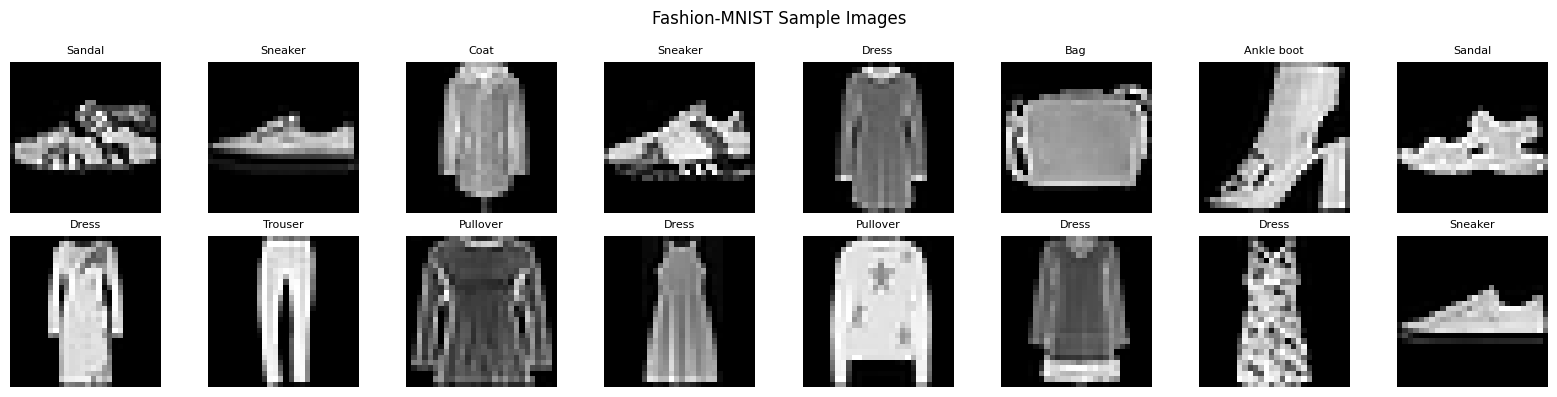

In [3]:
# Visualize sample images — provided
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img = images[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASS_NAMES[labels[i]], fontsize=8)
    ax.axis('off')
plt.suptitle("Fashion-MNIST Sample Images", fontsize=12)
plt.tight_layout(); plt.show()


---
## Step 4. 모델 설계 ✏️ 직접 구현

MLP 모델을 설계하세요.

**힌트**:
- 입력: 28×28 = **784** 차원 (이미지를 1D로 펼쳐야 합니다)
- 출력: **10** 클래스
- 은닉층 구조는 자유롭게 설계하세요
- 다중분류이므로 출력층 활성화 함수는 **Softmax가 아닌 Linear** 그대로 둡니다  
  (`nn.CrossEntropyLoss`가 내부적으로 Softmax를 포함합니다)

```
입력 (784) → 은닉층 → ... → 출력 (10)
```


In [4]:
class FashionMLP(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super().__init__()
        # 입력층 (784 -> 256)
        self.fc1 = nn.Linear(784, 256)
       
        # 배치 정규화
        self.bn1 = nn.BatchNorm1d(256)
       
        # 은닉층의 출력에 비선형성 도입
        self.relu = nn.ReLU()
       
        # Dropout
        self.dropout = nn.Dropout(p=dropout_rate)
       
        # 출력층: 256개의 특징을 10개의 클래스 로짓(Logit)으로 변환
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        # 1. Flattening
        # 차원 변화: (Batch, 1, 28, 28) -> (Batch, 784)
        x = x.view(x.size(0), -1)
       
        # 2. 첫 번째 선형 계층
        # 차원 변화: (Batch, 784) -> (Batch, 256)
        x = self.fc1(x)
       
        # 3. [추가] 배치 정규화 통과 (차원 유지)
        x = self.bn1(x)
       
        # 4. 활성화 함수 및 [추가] 드롭아웃 통과 (차원 유지)
        x = self.relu(x)
        x = self.dropout(x)
       
        # 5. 출력층
        # 차원 변화: (Batch, 256) -> (Batch, 10)
        x = self.fc2(x)
        return x

# Model test
# 생성한 모델 객체를 지정된 연산 장치(CPU or GPU)로 메모리 할당
model = FashionMLP().to(device)
print(model)

# 모델이 가진 전체 학습 가능한 파라미터(Weight + Bias) 개수 확인
# 연산: (784*256 + 256) + (256*10 + 10) = 203,530
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Shape test
x_test = torch.randn(4, 1, 28, 28).to(device)
out    = model(x_test)
print(f"Output shape: {out.shape}")   # Expected: torch.Size([4, 10])

FashionMLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Total parameters: 204,042
Output shape: torch.Size([4, 10])


---
## Step 5. 학습 루프 ✏️ 직접 구현

**힌트**:
- Loss function: `nn.CrossEntropyLoss()` (다중분류)
- Optimizer: `torch.optim.Adam`
- 배치 루프가 추가됩니다 — DataLoader에서 배치를 꺼내서 학습합니다

```python
for epoch in range(num_epochs):
    for images, labels in train_loader:   # ← 배치 루프 추가
        images, labels = images.to(device), labels.to(device)
        # 학습 5단계 ...
```


In [5]:
# 다중 클래스 분류를 위한 손실 함수 설정 (내부적으로 Softmax 연산을 포함)
criterion = nn.CrossEntropyLoss()   # ✏️ 다중분류 loss

# optimizer로 Adam 사용 (학습률 0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)   # ✏️ optimizer (lr=0.001 권장)

num_epochs = 10
# 에폭마다의 손실과 정확도 추이를 기록할 리스트 초기화
train_losses, test_losses, test_accs = [], [], []

for epoch in range(num_epochs):
    # --- Train ---
    # 모델을 학습 모드로 설정 (학습 시에만 사용하는 레이어의 동작을 활성화)
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        # ✏️ 학습 5단계를 구현하세요

        # 1. zero_grad
        optimizer.zero_grad()
        # 2. forward
        outputs = model(images)
        # 3. loss
        loss = criterion(outputs, labels)
        # 4. backward
        loss.backward()
        # 5. step
        optimizer.step()

        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # --- Evaluate ---
    # 모델을 평가 모드로 전환
    model.eval()
    correct, total, te_loss = 0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            te_loss  += criterion(outputs, labels).item()
            
            # 정확도 계산: outputs(로짓) 중 가장 값이 큰 인덱스가 최종 예측 클래스
            # torch.max는 (최대값, 인덱스)를 반환하므로 값은 버리고(_) 두 번째 인자(인덱스)만 사용
            _, predicted = torch.max(outputs, dim=1) 

            # 예측값과 실제 정답이 일치하는 개수를 합산하여 맞춘 횟수 누적
            correct += (predicted == labels).sum().item()
            # 평가한 전체 데이터의 개수 누적
            total   += labels.size(0)

    # 1에폭 동안의 평균 테스트 손실 및 정확도 저장
    test_losses.append(te_loss / len(test_loader))
    test_accs.append(correct / total)

    # 현재 에폭의 훈련 및 평가 결과 출력
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_losses[-1]:.4f} | "
          f"Test Loss: {test_losses[-1]:.4f} | "
          f"Test Acc: {test_accs[-1]*100:.1f}%")


Epoch  1/10 | Train Loss: 0.5003 | Test Loss: 0.4172 | Test Acc: 84.7%
Epoch  2/10 | Train Loss: 0.3979 | Test Loss: 0.3762 | Test Acc: 86.7%
Epoch  3/10 | Train Loss: 0.3665 | Test Loss: 0.3582 | Test Acc: 87.1%
Epoch  4/10 | Train Loss: 0.3488 | Test Loss: 0.3421 | Test Acc: 87.6%
Epoch  5/10 | Train Loss: 0.3323 | Test Loss: 0.3400 | Test Acc: 87.7%
Epoch  6/10 | Train Loss: 0.3185 | Test Loss: 0.3326 | Test Acc: 88.2%
Epoch  7/10 | Train Loss: 0.3059 | Test Loss: 0.3270 | Test Acc: 88.3%
Epoch  8/10 | Train Loss: 0.3001 | Test Loss: 0.3354 | Test Acc: 87.7%
Epoch  9/10 | Train Loss: 0.2903 | Test Loss: 0.3166 | Test Acc: 88.7%
Epoch 10/10 | Train Loss: 0.2822 | Test Loss: 0.3250 | Test Acc: 88.3%


---
## Step 6. 학습 곡선 시각화 (코드 제공 — 수정 불필요)


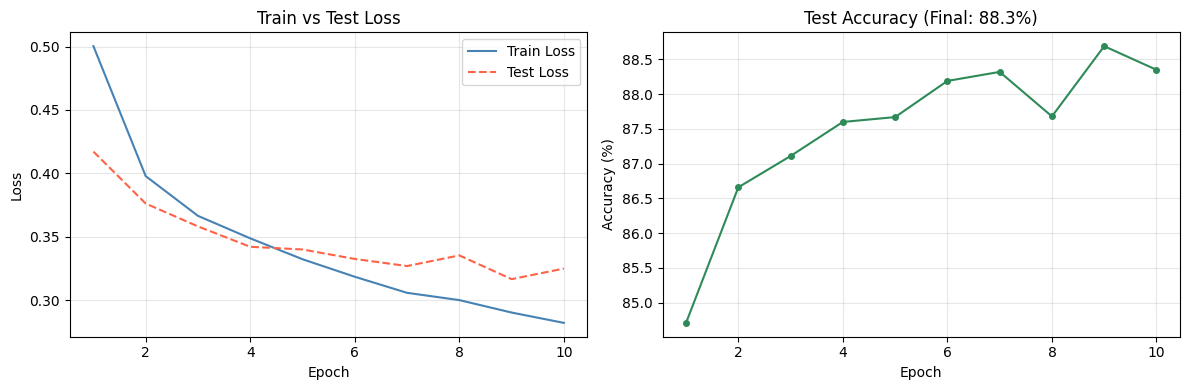

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


# [왼쪽 그래프] Train Loss와 Test Loss의 변화 추이 시각화
# Train Loss는 감소하지만 Test Loss가 멈추거나 상승한다면 과적합(Overfitting)을 의심할 수 있음
axes[0].plot(range(1, num_epochs+1), train_losses, label='Train Loss', color='steelblue')
axes[0].plot(range(1, num_epochs+1), test_losses,  label='Test Loss',  color='tomato', linestyle='--')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Test Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# [오른쪽 그래프] Test Accuracy의 변화 추이 시각화
# 에폭이 지날수록 모델의 분류 성능이 어떻게 향상되는지 백분율(%)로 표기
axes[1].plot(range(1, num_epochs+1), [a*100 for a in test_accs], color='seagreen', marker='o', markersize=4)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title(f"Test Accuracy (Final: {test_accs[-1]*100:.1f}%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


---
## Step 7. 예측 결과 시각화 (코드 제공 — 수정 불필요)

모델이 어떤 클래스를 헷갈려하는지 확인합니다.


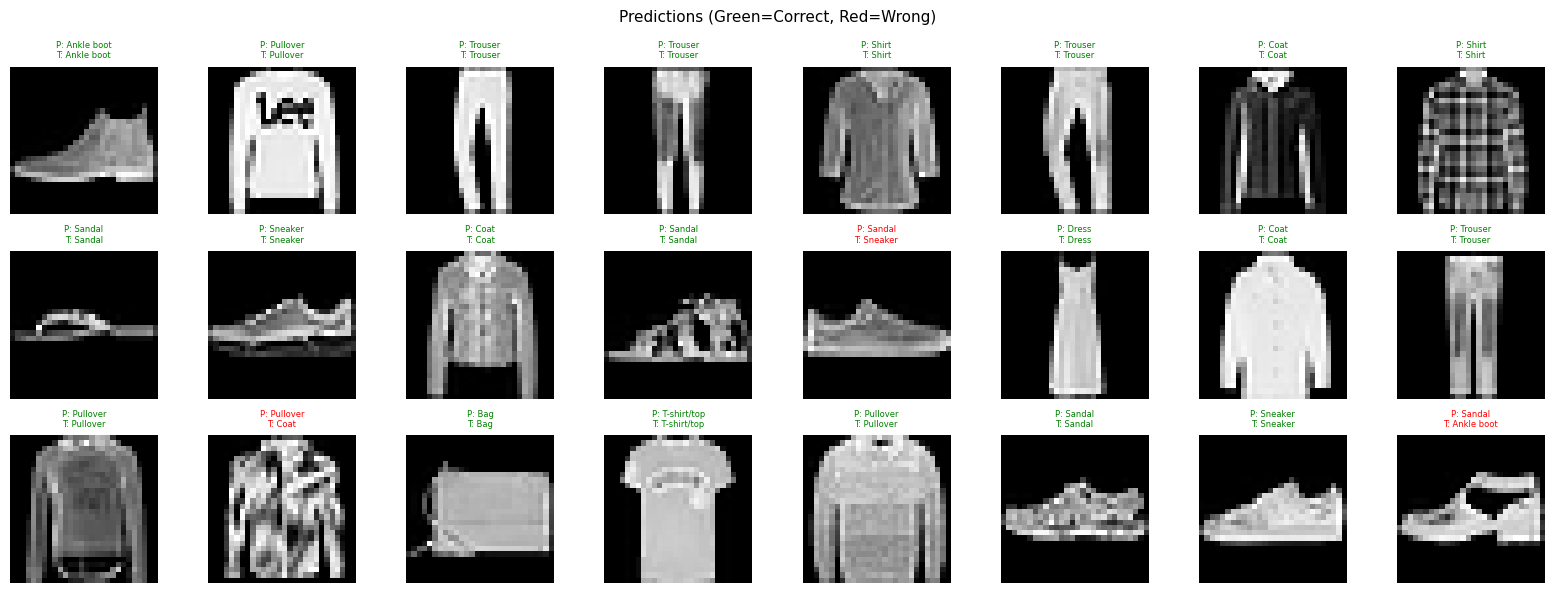

In [7]:
# Visualize predictions — provided
model.eval()
images_vis, labels_vis = next(iter(test_loader))
images_vis = images_vis.to(device)

with torch.no_grad():
    outputs_vis = model(images_vis)
    _, preds_vis = torch.max(outputs_vis, 1)

fig, axes = plt.subplots(3, 8, figsize=(16, 6))
for i, ax in enumerate(axes.flatten()):
    img = images_vis[i].cpu().squeeze().numpy()
    pred  = CLASS_NAMES[preds_vis[i].item()]
    true  = CLASS_NAMES[labels_vis[i].item()]
    
    # 예측이 실제 정답과 일치하면 텍스트 색상을 초록색, 틀리면 빨간색으로 지정
    color = 'green' if pred == true else 'red'
    ax.imshow(img, cmap='gray')

    # 이미지 상단에 예측값(P)과 실제 정답(T)을 표시
    ax.set_title(f"P: {pred}\nT: {true}", fontsize=6, color=color)
    ax.axis('off')


plt.suptitle("Predictions (Green=Correct, Red=Wrong)", fontsize=11)
plt.tight_layout(); plt.show()


---
## Step 8. 틀린 샘플 분석 ✏️ 직접 구현

모델이 **가장 많이 헷갈리는 클래스 쌍**을 찾아보세요.

**힌트**: Confusion Matrix를 사용하면 됩니다.


In [8]:
# %pip install seaborn

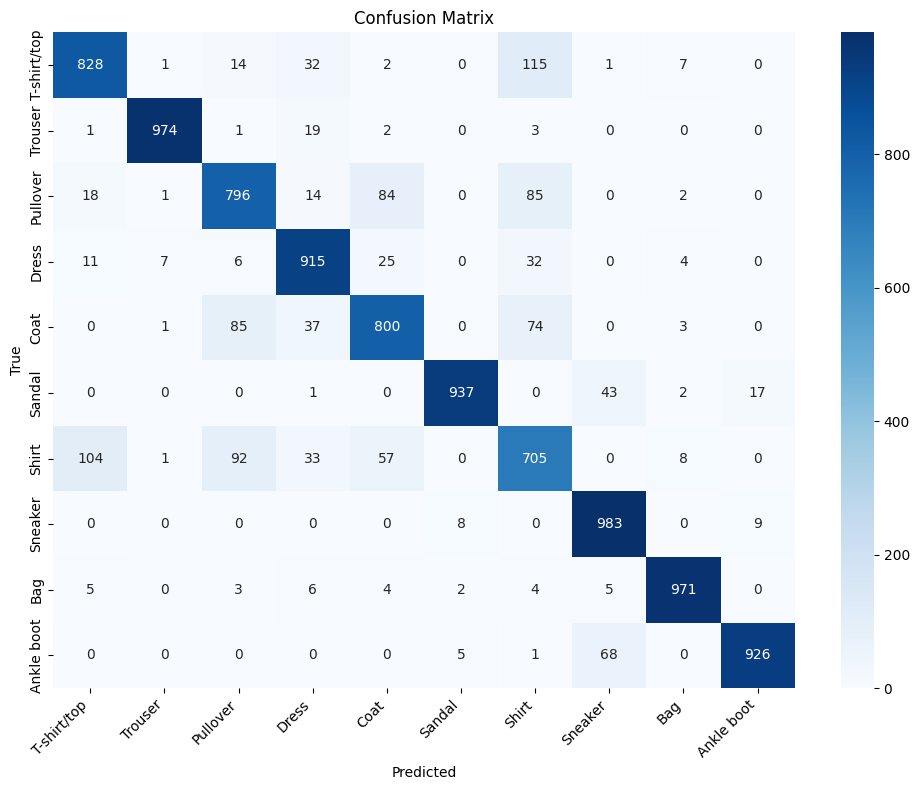


Most confused pairs:
  True: T-shirt/top     → Predicted: Shirt           (115번)
  True: Shirt           → Predicted: T-shirt/top     (104번)
  True: Shirt           → Predicted: Pullover        (92번)


In [9]:

from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []

# 평가 모드 설정 (학습 관련 레이어 비활성화)
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        # ✏️ 예측 클래스를 구해서 all_preds, all_labels에 추가하세요
        # 각 이미지에 대한 최종 예측 클래스 인덱스 추출
        _, predicted = torch.max(outputs, dim=1)
        all_preds.append(predicted.cpu())
        all_labels.append(labels.cpu())

all_preds  = torch.cat(all_preds).cpu().numpy()
all_labels = torch.cat(all_labels).cpu().numpy()

# 혼동 행렬(Confusion Matrix) 시각화
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

# Most confused pairs
print("\nMost confused pairs:")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# 오답 빈도가 가장 높은 상위 3개의 쌍을 찾아 출력
for _ in range(3):
    # 2차원 배열에서 가장 큰 값의 위치(행, 열 인덱스)를 찾음
    idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    print(f"  True: {CLASS_NAMES[idx[0]]:15s} → Predicted: {CLASS_NAMES[idx[1]]:15s} ({cm_no_diag[idx]}번)")
    cm_no_diag[idx] = 0


---
## 제출 체크리스트

- [ ] Step 4: 모델 구조를 직접 설계했다
- [ ] Step 5: 학습 루프를 완성했다
- [ ] Step 5: 정확도 계산 코드를 완성했다
- [ ] Step 8: Confusion Matrix를 완성했다
- [ ] 모든 셀을 실행하여 출력 결과가 있다

---

## 보고 질문 (주관식, 간단히)

1. 최종 Test Accuracy는 몇 %였나요? 모델 구조(레이어 수, 뉴런 수)도 함께 적어주세요.

2. Confusion Matrix에서 가장 많이 헷갈리는 클래스 쌍은 무엇인가요? 왜 헷갈릴 것 같은지 한 문장으로 설명하세요.

3. 에폭을 늘리거나 모델 구조를 바꾸면 어떻게 될까요? 실험해보고 결과를 적어주세요. (선택)


---
1. 최종 test Accuracy: `88.3%`
   - 모델 구조: `2층` (입력층 784 → 은닉층 256 → 출력층 10)
    

2. 티셔츠/상의 <-> 셔츠의 쌍은 양방향으로 아주 혼동함. (115회/104회)
   - MNIST 데이터에선 낮은 해상도의 흑백 이미지이기 때문에 옷깃, 단추 등의 디테일이 뭉개져 전반적인 실루엣이 유사하게 나왔을것으로 추정됨.


3. 에폭을 늘리거나 모델 구조를 바꾸면 어떻게 될까요? 실험해보고 결과를 적어주세요. - 하단에 작성

In [ ]:
import torch
import torch.nn as nn

class DeepFashionMLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[512,256], num_classes=10, dropout_rate=0.4):
        super().__init__()
        
        # 1. 입력 이미지를 1D로 펴주는 계층
        self.flatten = nn.Flatten()
        
        # 2. 은닉층들을 담을 ModuleList 컨테이너 생성
        self.hidden_layers = nn.ModuleList()
        
        # 차원 추적을 위한 변수 초기화
        in_features = input_size
        
        # 3. hidden_sizes 리스트를 순회하며 동적으로 Layer Block 생성
        for h_size in hidden_sizes:
            # Linear -> BatchNorm -> ReLU -> Dropout 구조를 하나의 Sequential 블록으로 묶음
            layer_block = nn.Sequential(
                nn.Linear(in_features, h_size),
                nn.BatchNorm1d(h_size),
                nn.ReLU(),
                nn.Dropout(p=dropout_rate)
            )
            self.hidden_layers.append(layer_block)
            
            # 다음 층의 입력 차원은 현재 층의 출력 차원(h_size)이 됨
            in_features = h_size
            
        # 4. 최종 출력층
        self.out_layer = nn.Linear(in_features, num_classes)

    def forward(self, x):
        # Flattening
        # shape: [batch_size, 1, 28, 28] -> [batch_size, 784]
        x = self.flatten(x)
        
        # 순차적으로 은닉층 통과
        for block in self.hidden_layers:
            # (Loop 1) shape: [batch_size, 784] -> [batch_size, 512]
            # (Loop 2) shape: [batch_size, 512] -> [batch_size, 256]
            # (BatchNorm, ReLU, Dropout은 차원 변경 없음)
            x = block(x)
            
        # 출력층
        # shape: [batch_size, 256] -> [batch_size, 10]
        x = self.out_layer(x)
        
        return x

# 모델 테스트 및 검증
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
deep_model = DeepFashionMLP(hidden_sizes=[512, 256]).to(device)

print(model)

# 전체 파라미터 개수 확인
# 1층: (784*512 + 512) + 512*2(BN) = 402,944
# 2층: (512*256 + 256) + 256*2(BN) = 131,840
# 출력층: (256*10 + 10) = 2,570
# Total = 537,354
print(f"\nTotal parameters: {sum(p.numel() for p in deep_model.parameters()):,}")

# 차원 변환(Shape) 테스트
x_test = torch.randn(4, 1, 28, 28).to(device)
out    = deep_model(x_test)
print(f"Output shape: {out.shape}")  

FashionMLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

Total parameters: 537,354
Output shape: torch.Size([4, 10])


In [14]:
optimizer_deep = torch.optim.Adam(deep_model.parameters(), lr=0.001)

# 에폭을 10 -> 15로 설정
deep_epoch = 15 
deep_train_losses, deep_test_losses, deep_test_accs = [], [], []

print("\n=== DeepFashionMLP 모델 훈련 시작 ===")
for epoch in range(deep_epoch):
    # --- Train ---
    # 모델을 학습 모드로 설정
    deep_model.train()
    epoch_loss = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # 학습 5단계 구현
        # 1. zero_grad
        optimizer_deep.zero_grad()

        # 2. forward
        outputs = deep_model(images)
        
        # 3. loss
        loss = criterion(outputs, labels)

        # 4. backward
        loss.backward()

        # 5. step
        optimizer_deep.step()
        # 현재 배치의 손실값을 누적
        epoch_loss += loss.item()

    # 1에폭 평균 훈련 손실 기록
    deep_train_losses.append(epoch_loss / len(train_loader))

    # --- Evaluate ---
    # 모델을 평가 모드로 전환
    deep_model.eval()
    correct, total, te_loss = 0, 0, 0

    # 평가 시에는 기울기 계산을 비활성화하여 자원 절약
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = deep_model(images)
            te_loss += criterion(outputs, labels).item()
            
            # 예측값 중 최대 인덱스 추출
            _, predicted = torch.max(outputs, dim=1) 

            # 정확도 계산을 위한 개수 합산
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    # 1에폭 평균 테스트 손실 및 정확도 기록
    deep_test_losses.append(te_loss / len(test_loader))
    deep_test_accs.append(correct / total)

    # 현재 에폭의 훈련 및 평가 결과 출력
    print(f"Epoch {epoch+1:2d}/{deep_epoch} | "
          f"Train Loss: {deep_train_losses[-1]:.4f} | "
          f"Test Loss: {deep_test_losses[-1]:.4f} | "
          f"Test Acc: {deep_test_accs[-1]*100:.1f}%")


=== DeepFashionMLP 모델 훈련 시작 ===
Epoch  1/15 | Train Loss: 0.4179 | Test Loss: 0.3709 | Test Acc: 86.1%
Epoch  2/15 | Train Loss: 0.3761 | Test Loss: 0.3525 | Test Acc: 86.9%
Epoch  3/15 | Train Loss: 0.3522 | Test Loss: 0.3485 | Test Acc: 87.2%
Epoch  4/15 | Train Loss: 0.3345 | Test Loss: 0.3279 | Test Acc: 87.6%
Epoch  5/15 | Train Loss: 0.3206 | Test Loss: 0.3217 | Test Acc: 88.5%
Epoch  6/15 | Train Loss: 0.3065 | Test Loss: 0.3198 | Test Acc: 88.4%
Epoch  7/15 | Train Loss: 0.2971 | Test Loss: 0.3102 | Test Acc: 88.6%
Epoch  8/15 | Train Loss: 0.2900 | Test Loss: 0.3141 | Test Acc: 88.5%
Epoch  9/15 | Train Loss: 0.2805 | Test Loss: 0.3016 | Test Acc: 89.0%
Epoch 10/15 | Train Loss: 0.2747 | Test Loss: 0.2968 | Test Acc: 89.2%
Epoch 11/15 | Train Loss: 0.2650 | Test Loss: 0.2976 | Test Acc: 89.1%
Epoch 12/15 | Train Loss: 0.2593 | Test Loss: 0.2941 | Test Acc: 89.3%
Epoch 13/15 | Train Loss: 0.2521 | Test Loss: 0.2921 | Test Acc: 89.6%
Epoch 14/15 | Train Loss: 0.2482 | Test Loss

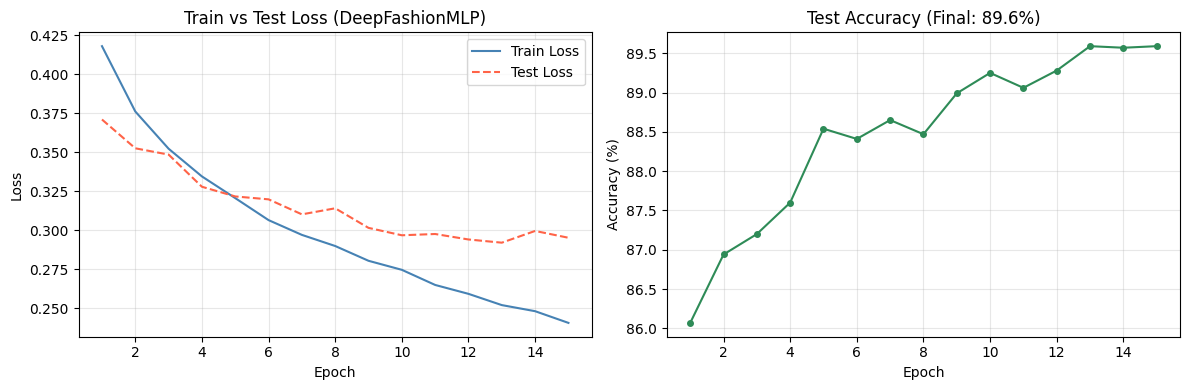

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# [왼쪽 그래프] Train Loss와 Test Loss의 변화 추이 시각화
axes[0].plot(range(1, deep_epoch+1), deep_train_losses, label='Train Loss', color='steelblue')
axes[0].plot(range(1, deep_epoch+1), deep_test_losses,  label='Test Loss',  color='tomato', linestyle='--')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Train vs Test Loss (DeepFashionMLP)"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# [오른쪽 그래프] Test Accuracy의 변화 추이 시각화
axes[1].plot(range(1, deep_epoch+1), [a*100 for a in deep_test_accs], color='seagreen', marker='o', markersize=4)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title(f"Test Accuracy (Final: {deep_test_accs[-1]*100:.1f}%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
 # 그래프 비교

 ## 초기 모델 그래프
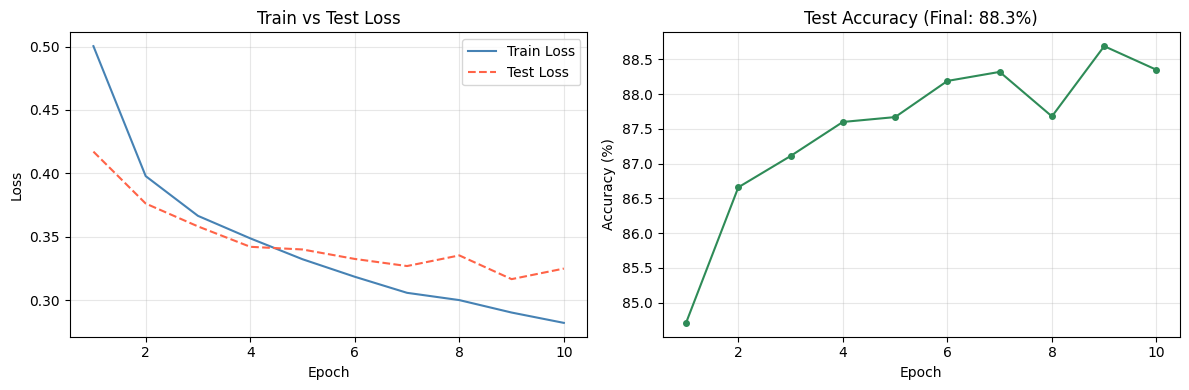

## 변경된 모델의 그래프
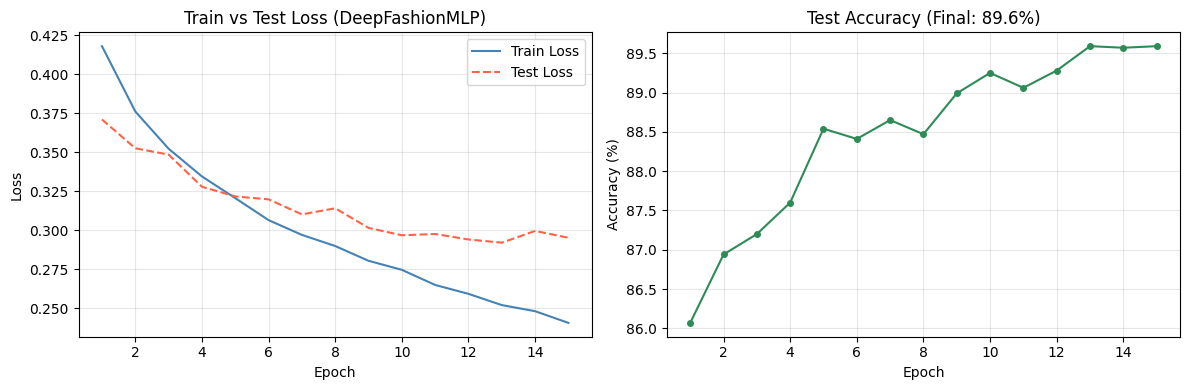

---
### 결론
1. 모델 구조의 변화
   - 기존 구조: 1개의 은닉층 (784 - 256 - 10) 
   - 변화된 구조: 2개의 은닉층 (784 - 512 - 256 - 10)
2. 실험 결과 및 분석
   - 성능: 모델의 깊이가 깊어짐에 따라 복잡한 패턴 인식이 가능해져 테스트 정확도가 소폭 향상됨. (88.3% -> 89.6%)
   - 현상: 하지만 28 * 28의 단순한 데이터 특성상, 에포크 증가에 따라 모델이 훈련 데이터를 과하게 학습하는 과적합이 관찰됨.
